### Monty Hall Problem (3 doors, 1 opened)

In [11]:
import random
import matplotlib.pyplot as plt

In [3]:
def monty_hall(switch):
    doors = [0, 0, 0]
    car_indx = random.randint(0,2) #I randomly select the index of one of the zeroes that will become the car (hence 1)
    doors[car_indx] = 1

    #The player chooses randomly:
    choice = random.randint(0,2)
    
    #I randomly eliminate one zero (goat) between the doors that have not been chosen:
    not_chosen = []
    for i in range(3): 
        if (i != choice and doors[i] == 0):
            not_chosen.append(i) #i know have the indexes (or index) of the doors containing a goat i can eliminate

    opened = random.choice(not_chosen)

    if switch:
        choice = [i for i in range(3) if i not in (choice, opened)][0]   

    if doors[choice] == 1:
        return 1
    else:
        return 0

In [4]:
def mh_newcomer():
    doors = [0, 0, 0]
    car_indx = random.randint(0,2) #I randomly select the index of one of the zeroes that will become the car (hence 1)
    doors[car_indx] = 1

    #The player chooses randomly:
    choice = random.randint(0,2)
    
    #I randomly eliminate one zero (goat) between the doors that have not been chosen:
    not_chosen = []
    for i in range(3): 
        if (i != choice and doors[i] == 0):
            not_chosen.append(i) #i know have the indexes (or index) of the doors containing a goat i can eliminate

    opened = random.choice(not_chosen)

    doors.pop(opened)

    new_choice = random.randint(0,1)

    if doors[new_choice] == 1:
        return 1
    else:
        return 0

In [14]:
#I want to simulate the problem N times for every case
N = 10000

In [6]:
#Switching player:
wins = 0
for _ in range(N):
    wins += monty_hall(switch=True)

switching = wins/N
print(switching)

0.66721


In [7]:
#Conservative player:
wins = 0
for _ in range(N):
    wins += monty_hall(switch=False)

conservative = wins/N
print(conservative)

0.33109


In [8]:
#Newcomer
wins = 0
for _ in range(N):
    wins += mh_newcomer()

newcomer = wins/N
print(newcomer)

0.5016


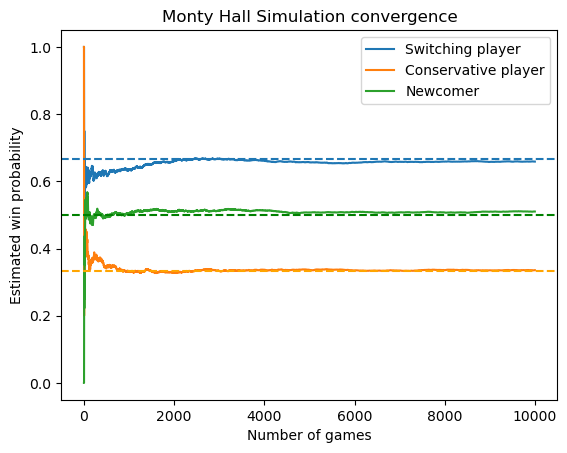

In [16]:
wins_switching = 0
wins_conservative = 0
wins_newcomer = 0

prob_switching = []
prob_conservative = []
prob_newcomer = []

for i in range(1, N+1):
    wins_switching += monty_hall(switch=True)
    wins_conservative += monty_hall(switch=False)
    wins_newcomer += mh_newcomer()

    prob_switching.append(wins_switching/i)
    prob_conservative.append(wins_conservative/i)
    prob_newcomer.append(wins_newcomer/i)

plt.plot(prob_switching, label="Switching player")
plt.plot(prob_conservative, label="Conservative player")
plt.plot(prob_newcomer, label="Newcomer")

plt.axhline(2/3, linestyle="--")
plt.axhline(1/3, linestyle="--", color="orange")
plt.axhline(1/2, linestyle="--", color="green")

plt.xlabel("Number of games")
plt.ylabel("Estimated win probability")
plt.title("Monty Hall Simulation convergence")
plt.legend()

plt.show()

### Generalization: N doors and p<N opened

In [17]:
def monty_gen(N, p):

    doors = [0]*N
    car = random.randint(0, N-1)
    doors[car] = 1

    choice = random.randint(0, N-1)

    #host now open p doors with goats
    possible = [i for i in range(N) if i != choice and doors[i] == 0]
    opened = random.sample(possible, p)

    closed = [i for i in range(N) if i not in opened]

    #conservative player
    conservative_win = doors[choice] == 1
    
    #switching player
    switch_options = [i for i in closed if i != choice]
    switch_choice = random.choice(switch_options)
    switching_win = doors[switch_choice] == 1

    #newcomer
    newcomer_choice = random.choice(closed)
    newcomer_win = doors[newcomer_choice] == 1

    return conservative_win, switching_win, newcomer_win    

In [22]:
def est_probs(N, p, trials=10000):
    stay = switch = new = 0

    for _ in range(trials):
        s, sw, n = monty_gen(N, p)

        stay += s
        switch += sw
        new += n

    return stay/trials, switch/trials, new/trials

Probability vs p

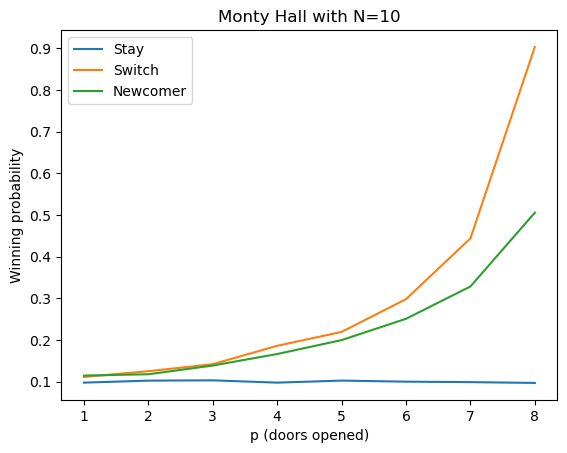

In [23]:
N = 10
ps = range(1,N-1)

stay_probs = []
switch_probs = []
new_probs = []

for p in ps:
    s, sw, n = est_probs(N, p)
    stay_probs.append(s)
    switch_probs.append(sw)
    new_probs.append(n)

plt.plot(ps, stay_probs, label="Stay")
plt.plot(ps, switch_probs, label="Switch")
plt.plot(ps, new_probs, label="Newcomer")

plt.xlabel("p (doors opened)")
plt.ylabel("Winning probability")
plt.title(f"Monty Hall with N={N}")
plt.legend()
plt.show()

Prob vs N (p fixed)

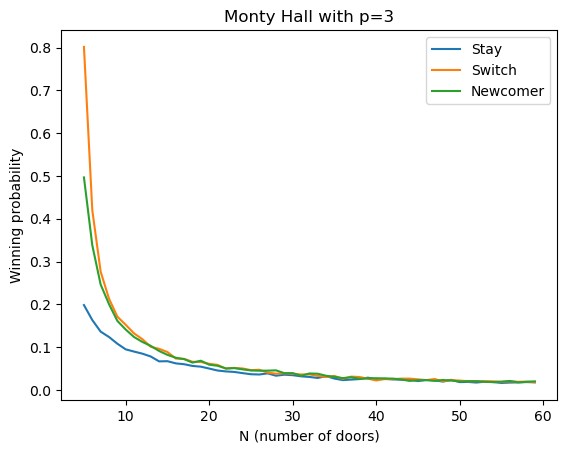

In [24]:
p = 3
Ns = range(5, 60)

stay_probs = []
switch_probs = []
new_probs = []

for N in Ns:
    s, sw, n = est_probs(N, p)

    stay_probs.append(s)
    switch_probs.append(sw)
    new_probs.append(n)

plt.plot(Ns, stay_probs, label="Stay")
plt.plot(Ns, switch_probs, label="Switch")
plt.plot(Ns, new_probs, label="Newcomer")

plt.xlabel("N (number of doors)")
plt.ylabel("Winning probability")
plt.title(f"Monty Hall with p={p}")
plt.legend()
plt.show()